# Creating ReAct-Agent from Scratch

AI agent that uses the “reasoning and acting” (ReAct) framework 

In [16]:
from langgraph.graph import StateGraph, MessagesState, START 
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_groq import ChatGroq
from langgraph.prebuilt import tools_condition # this is the checker for the if you got a tool back
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display


In [2]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")


In [3]:
llm = ChatGroq(model="openai/gpt-oss-120b")


In [4]:

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [12]:
# search tools
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

search.invoke("How old is Brad Pitt?")

'19-Dec-2025 · BRAD PITT AT 62 — AND THIS IS WHAT HE\'S REALLY EXCITED FOR Birthday candles, girlfriend Ines de Ramon, and a major life pivot. Brad\'s stepping back from ... 18-Dec-2025 · Brad Pitt marked his 62nd birthday on Dec. 18, and a source tells PEOPLE he\'s "doing well" and "excited" about his future with girlfriend Ines de Ramon: ... 18-Dec-2025 · Brad Pitt is celebrating his 62nd birthday today, marking more than three decades as one of Hollywood\'s most enduring stars. 6 days ago · Byname of: William Bradley Pitt ; Born: December 18, 1963, Shawnee, Oklahoma, U.S. (age 62) ; Awards And Honors: Academy Award (2020) ; Notable Family Members: ... 24-Jul-2025 · At 62, Brad Pitt stands as a symbol of timeless stardom—an artist whose legacy is built on range, presence, and an ever-deepening commitment to craft. Here\'s to ...'

In [13]:
# import sys
# print(sys.executable)

In [14]:
tools = [add, multiply, divide, search]

llm_with_tools = llm.bind_tools(tools)

In [15]:
def reasoner(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

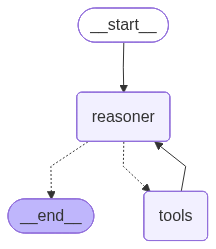

In [17]:
# Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("reasoner", reasoner)
builder.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
builder.add_edge(START, "reasoner")
builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

# Display the graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [18]:
messages = [HumanMessage(content="What is 2 times Brad Pitt's age?")]
messages = react_graph.invoke({"messages": messages})

In [19]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times Brad Pitt's age?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (fc_777a6d40-4728-40cd-8639-f4ed376e5f50)
 Call ID: fc_777a6d40-4728-40cd-8639-f4ed376e5f50
  Args:
    query: Brad Pitt age
================================= Tool Message =================================
Name: duckduckgo_search

2 weeks ago - Pitt's relationships have also been subject to widespread media attention, particularly his marriages to actresses Jennifer Aniston and Angelina Jolie, the latter of whom he shares six children with. William Bradley Pitt was born on December 18, 1963, in Shawnee, Oklahoma, to William Alvin ... 2 weeks ago - His acting career began at age 23 in 1987 with roles in the hit Fox television series 21 Jump Street. He subsequently appeared in episodes for television shows during the late 1980s and played his first major role in t